In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
df = pd.read_csv("Student_Performance.csv")

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
## checking basic info about the data 

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
## checking for duplicate value 

df.duplicated().sum()


np.int64(127)

In [6]:
## dropping the duplicated value 

df.drop_duplicates(inplace=True)


In [7]:
## checking for duplicate value 

df.duplicated().sum()


np.int64(0)

In [8]:
df.shape

(9873, 6)

In [9]:
## checking for null value 

df.isna().sum()


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [10]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [11]:
## converting extracurricular to 1, 0  

df['Extracurricular Activities'] = np.where(df['Extracurricular Activities'] == 'No' ,0,1 )


In [12]:
df['Extracurricular Activities']

0       1
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    1
9999    0
Name: Extracurricular Activities, Length: 9873, dtype: int64

In [13]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [14]:
## independent and dependet variable 

X = df.iloc[: , :-1]
y = df['Performance Index']

In [15]:
### splitting the data into training and testing part 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)



In [16]:
## standarziation 

from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [17]:
## training the linear regression model 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 

linRegressor = LinearRegression()
linRegressor.fit(X_train , y_train)
y_pred = linRegressor.predict(X_test)
print("r2 score :" , r2_score(y_test , y_pred))
print("mae :" , mean_absolute_error(y_test , y_pred))
print("mse :" , mean_squared_error(y_test , y_pred))




r2 score : 0.9884301209927054
mae : 1.6469703984255548
mse : 4.3059009385384694


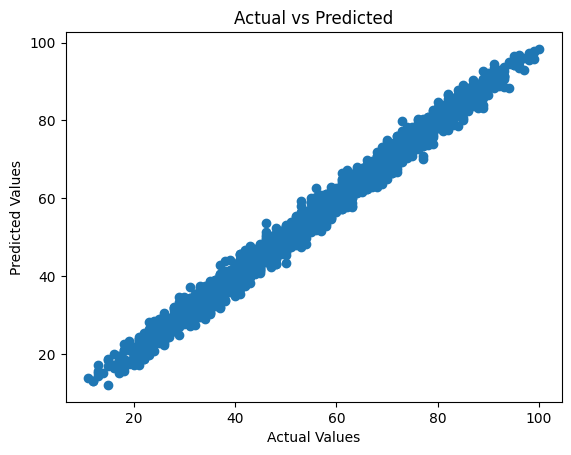

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

## Ridge Regression

In [19]:
## training the Rigde regression model 
from sklearn.linear_model import Ridge 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 

RigdeRegressor = Ridge()
RigdeRegressor.fit(X_train , y_train)
y_pred_ridge = RigdeRegressor.predict(X_test)
print("r2 score :" , r2_score(y_test , y_pred_ridge))
print("mae :" , mean_absolute_error(y_test , y_pred_ridge))
print("mse :" , mean_squared_error(y_test , y_pred_ridge))




r2 score : 0.9884300032844406
mae : 1.6469540715121593
mse : 4.3059447454034805


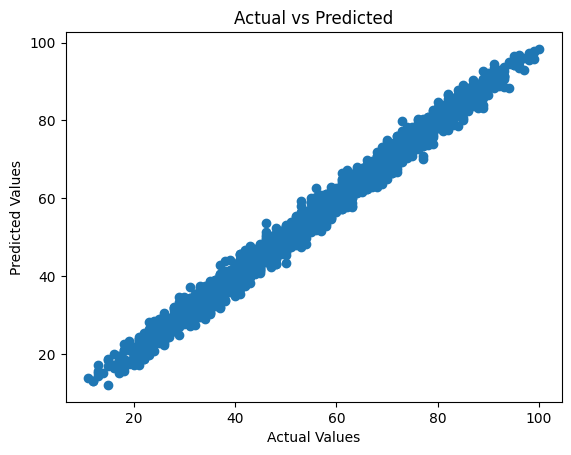

In [20]:
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

## Lasso Regression

In [21]:
## training the Lasso regression model 
from sklearn.linear_model import Lasso 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 

LassoRegressor = Lasso()
LassoRegressor.fit(X_train , y_train)
y_pred_lasso = LassoRegressor.predict(X_test)
print("r2 score :" , r2_score(y_test , y_pred_lasso))
print("mae :" , mean_absolute_error(y_test , y_pred_lasso))
print("mse :" , mean_squared_error(y_test , y_pred_lasso))




r2 score : 0.9792386037552545
mae : 2.2131657360409194
mse : 7.726659502597726


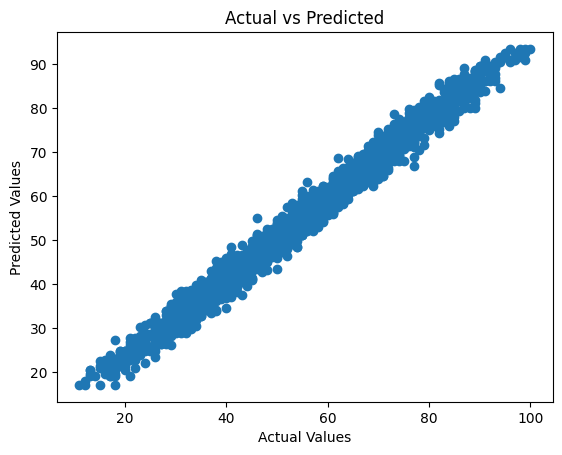

In [22]:
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

## Elastic net

In [23]:
## training the Elastic net model 
from sklearn.linear_model import ElasticNet 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 

ElasticNetRegressor = ElasticNet()
ElasticNetRegressor.fit(X_train , y_train)
y_pred_elastic = ElasticNetRegressor.predict(X_test)
print("r2 score :" , r2_score(y_test , y_pred_elastic))
print("mae :" , mean_absolute_error(y_test , y_pred_elastic))
print("mse :" , mean_squared_error(y_test , y_pred_elastic))




r2 score : 0.8590912422624478
mae : 6.022545830989442
mse : 52.44127028535724


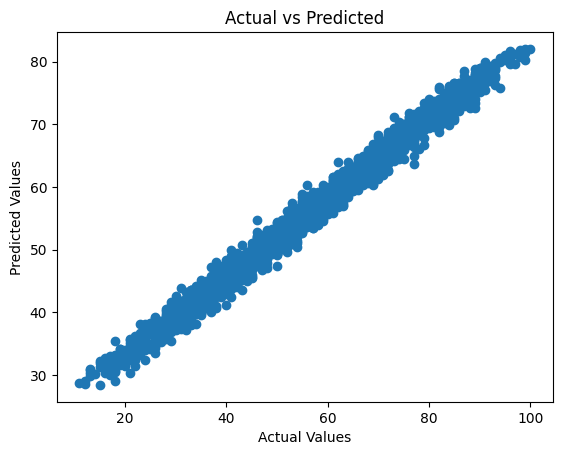

In [24]:
plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [25]:
## pickle file 

import pickle 

pickle.dump(linRegressor , open('linRegressor.pkl' ,  'wb'))
pickle.dump(scaler , open('scaler.pkl' ,  'wb'))

In [26]:
lin_reg = pickle.load(open("linRegressor.pkl" , 'rb'))

In [29]:
lin_reg.predict(res)

array([344.75105687])

In [28]:
res = scaler.transform([[99 , 90, 1,9,0]])


res

d:\udmey_ds_course\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[36.35046887,  1.19473386,  1.00609607,  1.44543968, -1.60657435]])